In [1]:
# Homework 1 Problem 2 - Modified VGGNet on CIFAR-10

import os, random, time, csv, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

seed = 42
epochs = 30
batch_size = 256
lr = 0.001
fast_cpu = True
alexnet_p1_params = 612042

if fast_cpu:
    train_size = 10000
    val_size = 2000
else:
    train_size = 45000
    val_size = 5000

random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, 'train:', train_size, 'val:', val_size)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
os.makedirs('Data', exist_ok=True); os.makedirs('Results_P2', exist_ok=True)

mean = (0.4914, 0.4822, 0.4465); std = (0.2470, 0.2435, 0.2616)
train_tf = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean,std)])
test_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean,std)])

train_all_aug = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=train_tf)
train_all_plain = torchvision.datasets.CIFAR10(root='Data', train=True, download=True, transform=test_tf)
test_data = torchvision.datasets.CIFAR10(root='Data', train=False, download=True, transform=test_tf)

gen = torch.Generator().manual_seed(seed)
idx = torch.randperm(50000, generator=gen).tolist()
train_idx = idx[:train_size]
val_idx = idx[45000:45000+val_size]

train_data = Subset(train_all_aug, train_idx)
val_data = Subset(train_all_plain, val_idx)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)
print(len(train_data), len(val_data), len(test_data))

device: cpu train: 10000 val: 2000
10000 2000 10000


In [2]:
class MyVGG(nn.Module):
    def __init__(self, drop=0.0, bn=True):
        super().__init__()
        # VGG style: repeated 3x3 convs, max pooling, small fully connected head.
        cfg = [32, 32, 'M', 64, 64, 'M', 128, 128, 'M', 128, 'M']
        layers = []
        c = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(2,2))
            else:
                layers.append(nn.Conv2d(c, v, 3, padding=1))
                if bn:
                    layers.append(nn.BatchNorm2d(v))
                layers.append(nn.ReLU())
                c = v
        self.features = nn.Sequential(*layers)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*2*2, 256), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(self.features(x))

def get_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

m = MyVGG(0, True).to(device)
print(m)
print('VGG params:', get_params(m))
print('AlexNet P1 params approx:', alexnet_p1_params)

MyVGG(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [3]:
def eval_model(model, loader):
    model.eval(); loss_fn = nn.CrossEntropyLoss(); total_loss=0; correct=0; total=0; ytrue=[]; ypred=[]
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device); y=y.to(device); out=model(x); loss=loss_fn(out,y)
            total_loss += loss.item()*x.size(0); pred=out.argmax(1); correct += (pred==y).sum().item(); total += y.size(0)
            ytrue += list(y.cpu().numpy()); ypred += list(pred.cpu().numpy())
    return total_loss/total, correct/total, ytrue, ypred

def train_model(name, drop, bn, wd):
    print('\nRUNNING:', name)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    folder = 'Results_P2/' + name; os.makedirs(folder, exist_ok=True)
    model = MyVGG(drop, bn).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)
    tl=[]; vl=[]; ta=[]; va=[]; best=0; start=time.time()
    for e in range(epochs):
        model.train(); total_loss=0; total_correct=0; total_seen=0
        for x,y in train_loader:
            x=x.to(device); y=y.to(device); optimizer.zero_grad(); out=model(x); loss=loss_fn(out,y); loss.backward(); optimizer.step()
            total_loss += loss.item()*x.size(0); pred=out.argmax(1); total_correct += (pred==y).sum().item(); total_seen += y.size(0)
        tr_loss=total_loss/total_seen; tr_acc=total_correct/total_seen; va_loss,va_acc,a,b=eval_model(model,val_loader); scheduler.step(va_loss)
        tl.append(tr_loss); vl.append(va_loss); ta.append(tr_acc); va.append(va_acc)
        if va_acc > best:
            best = va_acc; torch.save(model.state_dict(), folder + '/best_model.pth')
        print(e+1, 'train loss', round(tr_loss,4), 'train acc', round(tr_acc,4), 'val loss', round(va_loss,4), 'val acc', round(va_acc,4))
    model.load_state_dict(torch.load(folder + '/best_model.pth', map_location=device))
    te_loss, te_acc, ytrue, ypred = eval_model(model, test_loader); elapsed=time.time()-start
    print('test acc =', te_acc, 'best val =', best, 'time =', elapsed)
    info = {'seed':seed,'epochs':epochs,'train_size':train_size,'val_size':val_size,'batch_size':batch_size,'dropout':drop,'batch_norm':bn,'weight_decay':wd,'params':get_params(model),'test_acc':te_acc,'best_val_acc':best,'time':elapsed,'hardware':torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}
    json.dump(info, open(folder + '/results.json','w'), indent=4)
    with open(folder + '/metrics.csv','w',newline='') as f:
        w=csv.writer(f); w.writerow(['epoch','train_loss','val_loss','train_acc','val_acc'])
        for i in range(epochs): w.writerow([i+1,tl[i],vl[i],ta[i],va[i]])
    plt.figure(figsize=(7,5)); plt.plot(tl,label='train loss'); plt.plot(vl,label='val loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(name+' loss'); plt.legend(); plt.grid(); plt.savefig(folder+'/loss.png',dpi=200); plt.show()
    plt.figure(figsize=(7,5)); plt.plot(ta,label='train acc'); plt.plot(va,label='val acc'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(name+' accuracy'); plt.legend(); plt.grid(); plt.savefig(folder+'/accuracy.png',dpi=200); plt.show()
    cm=confusion_matrix(ytrue,ypred); disp=ConfusionMatrixDisplay(cm,display_labels=classes); fig,ax=plt.subplots(figsize=(10,8)); disp.plot(ax=ax,xticks_rotation=45,cmap='Blues'); plt.title(name+' confusion matrix'); plt.savefig(folder+'/confusion_matrix.png',dpi=200,bbox_inches='tight'); plt.show()
    return model, tl, vl, ta, va, info


RUNNING: vgg_baseline
1 train loss 1.6975 train acc 0.3619 val loss 1.7963 val acc 0.3445
2 train loss 1.2845 train acc 0.5184 val loss 1.3035 val acc 0.5255
3 train loss 1.0696 train acc 0.6138 val loss 1.494 val acc 0.5075
4 train loss 0.9474 train acc 0.6593 val loss 1.3254 val acc 0.5455
5 train loss 0.8499 train acc 0.7014 val loss 1.1106 val acc 0.634
6 train loss 0.7731 train acc 0.7272 val loss 1.0756 val acc 0.62
7 train loss 0.6888 train acc 0.7557 val loss 1.0899 val acc 0.6185
8 train loss 0.6096 train acc 0.7872 val loss 1.0938 val acc 0.6585
9 train loss 0.5676 train acc 0.802 val loss 1.3043 val acc 0.6145
10 train loss 0.5398 train acc 0.8109 val loss 0.9745 val acc 0.6755
11 train loss 0.4599 train acc 0.8432 val loss 1.0598 val acc 0.669
12 train loss 0.44 train acc 0.8478 val loss 1.0396 val acc 0.67
13 train loss 0.3731 train acc 0.867 val loss 1.0731 val acc 0.6855
14 train loss 0.4106 train acc 0.8556 val loss 0.8924 val acc 0.716
15 train loss 0.3156 train acc 0

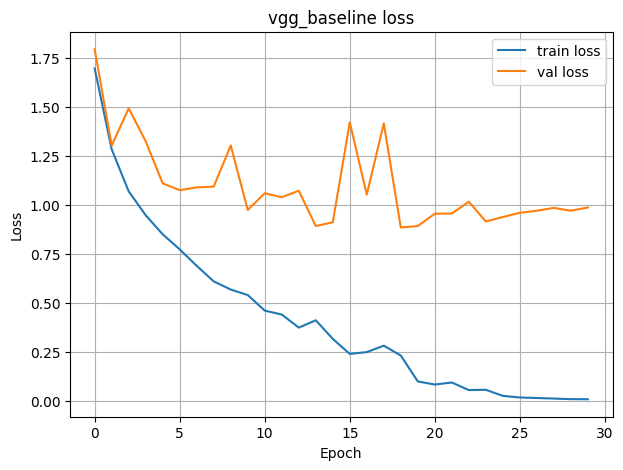

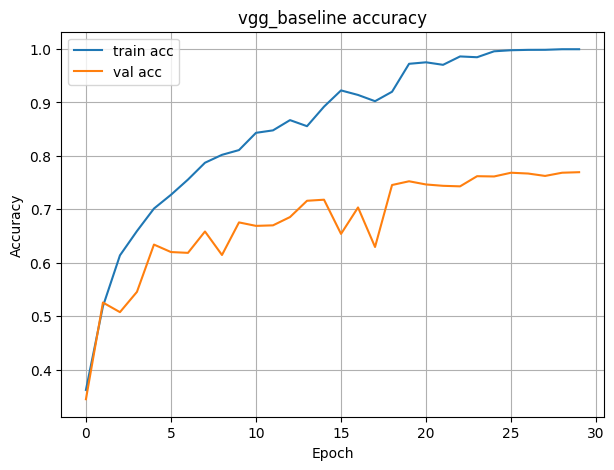

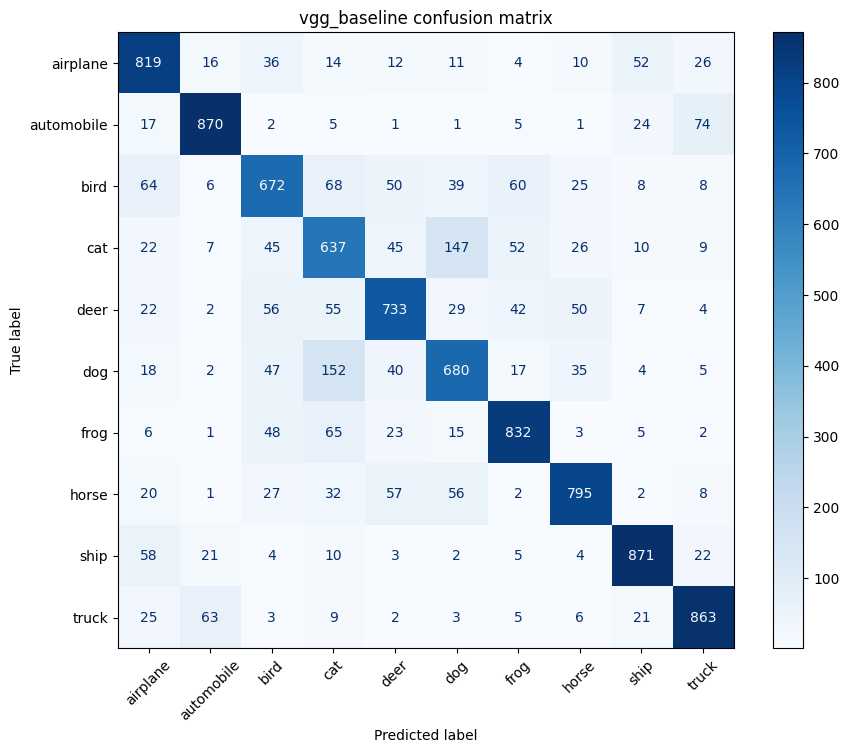


RUNNING: vgg_dropout_03
1 train loss 1.8685 train acc 0.2831 val loss 2.0016 val acc 0.303
2 train loss 1.5019 train acc 0.4223 val loss 1.5127 val acc 0.446
3 train loss 1.2933 train acc 0.5286 val loss 1.5236 val acc 0.4565
4 train loss 1.1216 train acc 0.5957 val loss 1.4701 val acc 0.4815
5 train loss 1.0598 train acc 0.6228 val loss 1.1273 val acc 0.606
6 train loss 0.966 train acc 0.6566 val loss 1.2985 val acc 0.5825
7 train loss 0.8758 train acc 0.6943 val loss 1.0014 val acc 0.655
8 train loss 0.8078 train acc 0.7141 val loss 1.145 val acc 0.6225
9 train loss 0.7992 train acc 0.7229 val loss 1.0485 val acc 0.628
10 train loss 0.6825 train acc 0.7647 val loss 1.097 val acc 0.6335
11 train loss 0.6934 train acc 0.7629 val loss 0.9367 val acc 0.6815
12 train loss 0.6182 train acc 0.7914 val loss 1.2125 val acc 0.6135
13 train loss 0.6393 train acc 0.7799 val loss 0.8235 val acc 0.726
14 train loss 0.5618 train acc 0.8085 val loss 0.9172 val acc 0.702
15 train loss 0.4821 train a

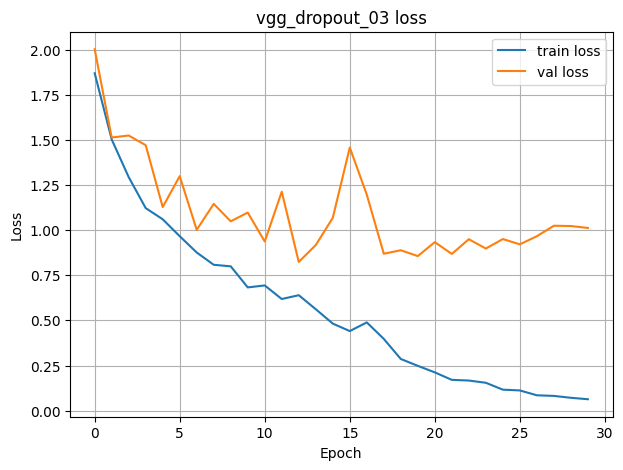

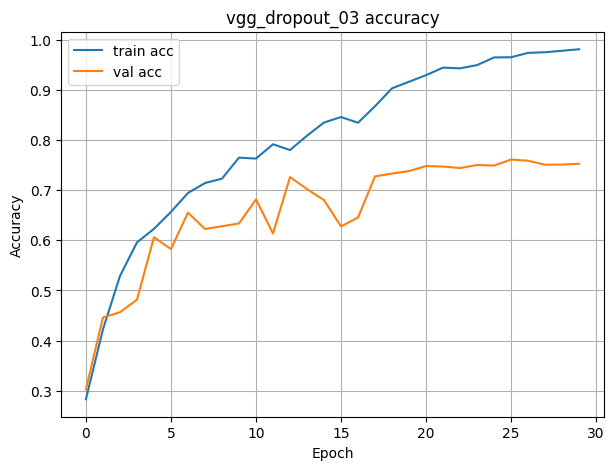

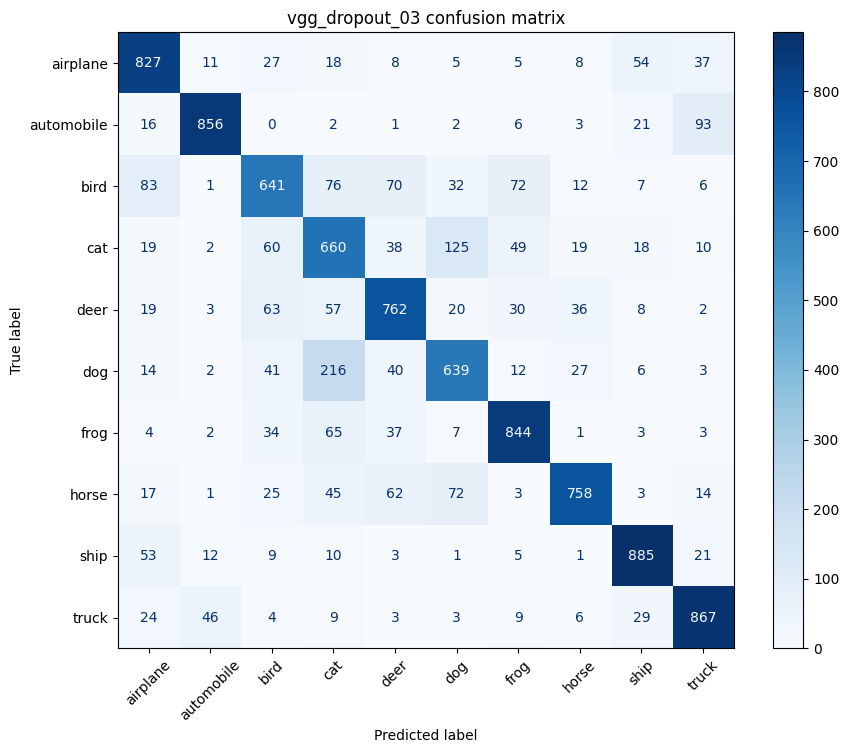


RUNNING: vgg_dropout_05
1 train loss 2.0162 train acc 0.2389 val loss 2.0579 val acc 0.285
2 train loss 1.644 train acc 0.359 val loss 1.7011 val acc 0.41
3 train loss 1.4802 train acc 0.4392 val loss 1.3874 val acc 0.4825
4 train loss 1.3154 train acc 0.5185 val loss 1.3362 val acc 0.501
5 train loss 1.2078 train acc 0.562 val loss 1.3737 val acc 0.532
6 train loss 1.1138 train acc 0.6064 val loss 1.5359 val acc 0.5345
7 train loss 1.0964 train acc 0.6169 val loss 1.1287 val acc 0.6135
8 train loss 0.9766 train acc 0.6546 val loss 1.1283 val acc 0.6235
9 train loss 0.9461 train acc 0.6744 val loss 1.0961 val acc 0.6015
10 train loss 0.84 train acc 0.7042 val loss 1.0148 val acc 0.644
11 train loss 0.8144 train acc 0.7185 val loss 1.1274 val acc 0.627
12 train loss 0.7323 train acc 0.7492 val loss 1.1764 val acc 0.622
13 train loss 0.7403 train acc 0.7462 val loss 0.9439 val acc 0.6845
14 train loss 0.7344 train acc 0.7493 val loss 0.9411 val acc 0.6875
15 train loss 0.6569 train acc 

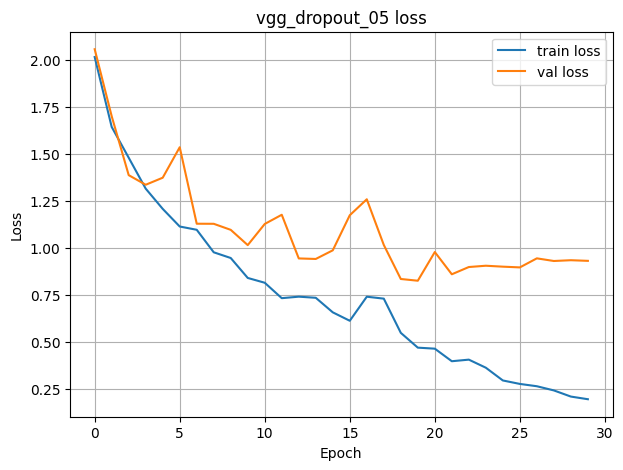

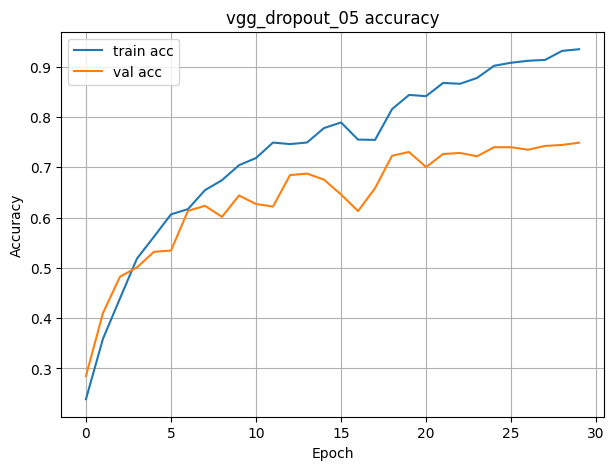

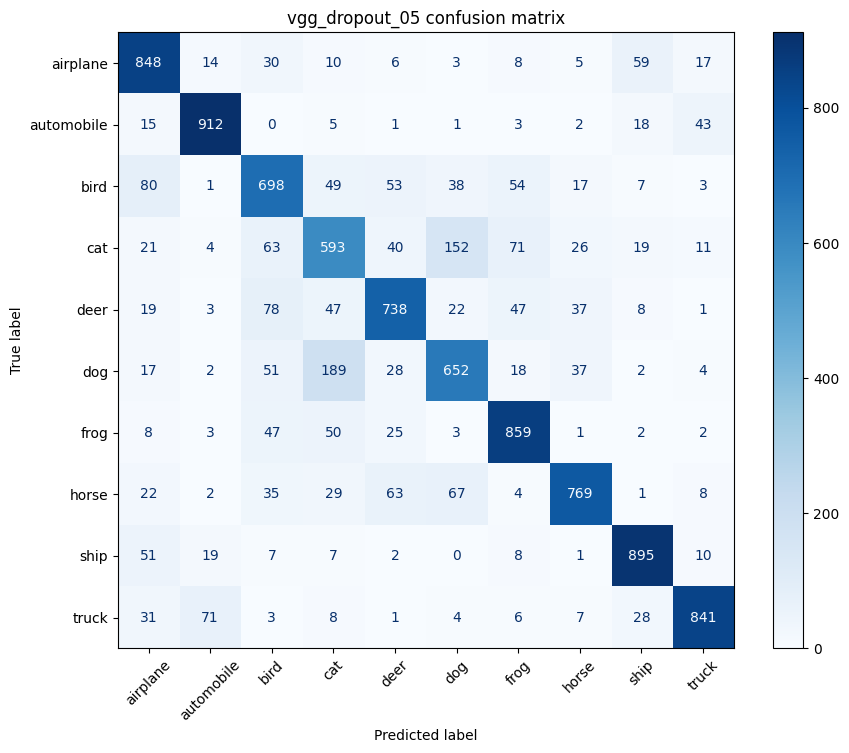


RUNNING: vgg_l2_bonus
1 train loss 1.697 train acc 0.3603 val loss 1.8458 val acc 0.3405
2 train loss 1.2929 train acc 0.5141 val loss 1.3416 val acc 0.5095
3 train loss 1.0762 train acc 0.6123 val loss 1.3663 val acc 0.5165
4 train loss 0.9368 train acc 0.663 val loss 1.5592 val acc 0.5135
5 train loss 0.8468 train acc 0.6991 val loss 1.0493 val acc 0.639
6 train loss 0.7557 train acc 0.7327 val loss 1.0855 val acc 0.6245
7 train loss 0.6755 train acc 0.7608 val loss 0.9987 val acc 0.6455
8 train loss 0.6083 train acc 0.7866 val loss 1.4556 val acc 0.61
9 train loss 0.5238 train acc 0.8135 val loss 1.1425 val acc 0.6435
10 train loss 0.5438 train acc 0.806 val loss 1.1556 val acc 0.648
11 train loss 0.4543 train acc 0.8412 val loss 0.8367 val acc 0.713
12 train loss 0.4395 train acc 0.8491 val loss 0.8858 val acc 0.705
13 train loss 0.3373 train acc 0.8864 val loss 0.9306 val acc 0.706
14 train loss 0.38 train acc 0.867 val loss 0.9116 val acc 0.7065
15 train loss 0.3462 train acc 0.

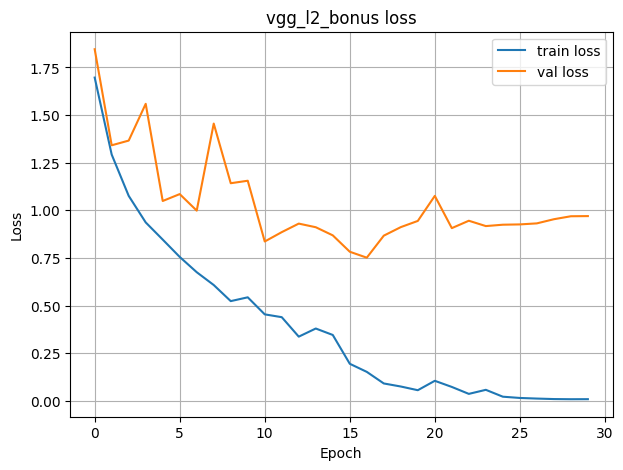

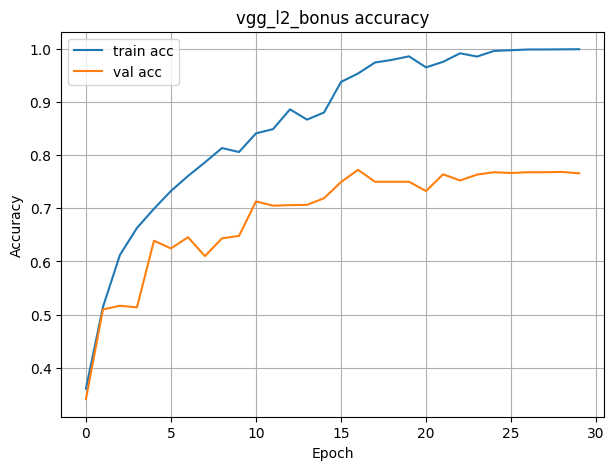

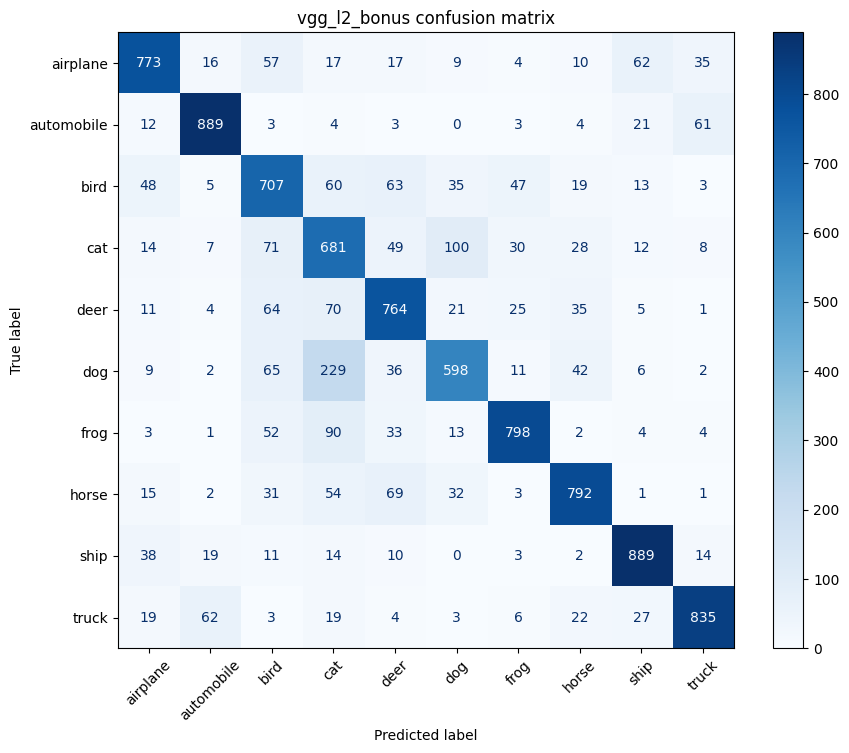

In [4]:
base_model, base_tl, base_vl, base_ta, base_va, base_info = train_model('vgg_baseline', 0.0, True, 0.0)
d03_model, d03_tl, d03_vl, d03_ta, d03_va, d03_info = train_model('vgg_dropout_03', 0.3, True, 0.0)
d05_model, d05_tl, d05_vl, d05_ta, d05_va, d05_info = train_model('vgg_dropout_05', 0.5, True, 0.0)
l2_model, l2_tl, l2_vl, l2_ta, l2_va, l2_info = train_model('vgg_l2_bonus', 0.0, True, 1e-4)

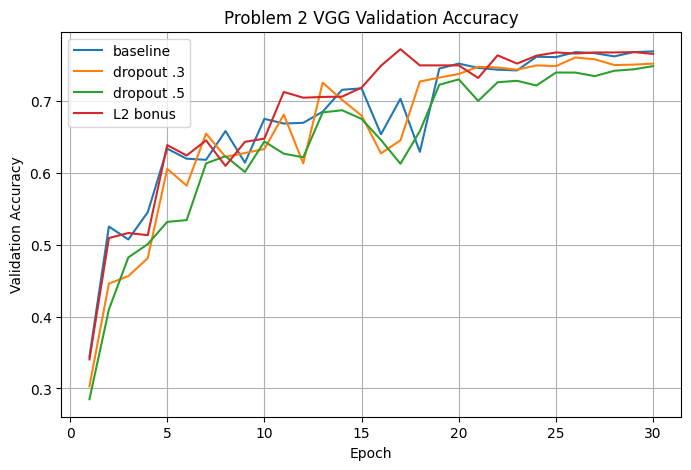

{'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'dropout': 0.0, 'batch_norm': True, 'weight_decay': 0.0, 'params': 601258, 'test_acc': 0.7772, 'best_val_acc': 0.7695, 'time': 2165.9441146850586, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'dropout': 0.3, 'batch_norm': True, 'weight_decay': 0.0, 'params': 601258, 'test_acc': 0.7739, 'best_val_acc': 0.761, 'time': 2553.021332025528, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'dropout': 0.5, 'batch_norm': True, 'weight_decay': 0.0, 'params': 601258, 'test_acc': 0.7805, 'best_val_acc': 0.749, 'time': 2474.826313495636, 'hardware': 'CPU'}
{'seed': 42, 'epochs': 30, 'train_size': 10000, 'val_size': 2000, 'batch_size': 256, 'dropout': 0.0, 'batch_norm': True, 'weight_decay': 0.0001, 'params': 601258, 'test_acc': 0.7726, 'best_val_acc': 0.7725, 'time': 2599.7049391269684, 'hardware': 'CPU

In [5]:
x=range(1,epochs+1)
plt.figure(figsize=(8,5)); plt.plot(x,base_va,label='baseline'); plt.plot(x,d03_va,label='dropout .3'); plt.plot(x,d05_va,label='dropout .5'); plt.plot(x,l2_va,label='L2 bonus'); plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy'); plt.title('Problem 2 VGG Validation Accuracy'); plt.legend(); plt.grid(); plt.savefig('Results_P2/val_acc_compare.png',dpi=200); plt.show()
print(base_info); print(d03_info); print(d05_info); print(l2_info)
print('Report note: VGG uses repeated 3x3 convolutions. I used a smaller VGG-style model so its parameter count is close to the AlexNet model.')